# 11 — Camera Binary Classifier Training

Train a **separate** binary camera-eye classifier (Normal vs Cataract) using `camera_dataset_prepared/`.

**This notebook does NOT:**
- modify `efficientnetv2_b0_4class_best.keras` or any existing model
- retrain or touch the 4-class fundus model
- modify the 5885-image fundus dataset or its CSVs
- modify Grad-CAM, FastAPI backend, or React frontend
- mix camera images with the fundus dataset

**Class mapping (camera dataset only):** `0 = Cataract` · `1 = Normal`

In [1]:
# CELL 1 — Imports, paths, config, protected-file fingerprints
from __future__ import annotations
import hashlib, json, warnings
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_fscore_support, f1_score
)

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

# ── Paths ──────────────────────────────────────────────────────────────────
PROJECT_ROOT_CANDIDATES = [Path.cwd(), Path.cwd().parent,
                            Path(r'D:/Practice Projects/Disease Detection')]
PROJECT_ROOT = next(
    (p for p in PROJECT_ROOT_CANDIDATES
     if (p / 'dataset').exists() and (p / 'preprocessing').exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not locate project root.')

PREPARED_DIR  = PROJECT_ROOT / 'camera_dataset_prepared'
MODEL_DIR     = PROJECT_ROOT / 'model'
REPORT_DIR    = PROJECT_ROOT / 'reports' / 'camera_classifier'
GRADCAM_DIR   = REPORT_DIR / 'gradcam'
MODEL_PATH    = MODEL_DIR / 'camera_binary_classifier_best.keras'

for d in [MODEL_DIR, REPORT_DIR, GRADCAM_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Config ─────────────────────────────────────────────────────────────────
IMG_SIZE      = 224
BATCH_SIZE    = 32
SEED          = 42
CLASS_MAP     = {0: 'Cataract', 1: 'Normal'}   # camera-only mapping
CLASS_NAMES   = ['Cataract', 'Normal']          # alphabetical = Keras default

# Dataset counts (from notebook 10)
TRAIN_COUNTS  = {'Cataract': 1110, 'Normal': 191}
VAL_COUNTS    = {'Cataract': 341,  'Normal': 38}
TEST_COUNTS   = {'Cataract': 161,  'Normal': 29}

TRAIN_TOTAL   = sum(TRAIN_COUNTS.values())   # 1301
VAL_TOTAL     = sum(VAL_COUNTS.values())     # 379
TEST_TOTAL    = sum(TEST_COUNTS.values())    # 190

# ── Protected-file fingerprints (taken BEFORE any writes) ──────────────────
PROTECTED_RELATIVE = [
    'preprocessing/dataset_metadata_v2.csv',
    'preprocessing/splits_v2/train.csv',
    'preprocessing/splits_v2/validation.csv',
    'preprocessing/splits_v2/test.csv',
    'model/efficientnetv2_b0_4class_best.keras',
    'model/efficientnetv2_b0_4class_final.keras',
    'model/model_metadata_v2.json',
    'reports/model_v2/test_metrics.json',
    'backend/app/main.py',
    'backend/app/model_service.py',
    'backend/app/gradcam.py',
    'frontend/package.json',
]

def _fingerprint(path: Path) -> dict:
    if not path.exists():
        return {'exists': False, 'size': None, 'md5': None, 'mtime_ns': None}
    data = path.read_bytes()
    return {'exists': True, 'size': len(data),
            'md5': hashlib.md5(data).hexdigest(),
            'mtime_ns': path.stat().st_mtime_ns}

PROTECTED_BEFORE = {r: _fingerprint(PROJECT_ROOT / r) for r in PROTECTED_RELATIVE}

print('PROJECT_ROOT :', PROJECT_ROOT)
print('PREPARED_DIR :', PREPARED_DIR, '| exists:', PREPARED_DIR.exists())
print('MODEL_PATH   :', MODEL_PATH)
print('REPORT_DIR   :', REPORT_DIR)
print('TF version   :', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices("GPU")))
print('Class map    :', CLASS_MAP)
print('Protected files fingerprinted:', len(PROTECTED_BEFORE))
print('Train:', TRAIN_TOTAL, '| Val:', VAL_TOTAL, '| Test:', TEST_TOTAL)

PROJECT_ROOT : d:\Practice Projects\Disease Detection
PREPARED_DIR : d:\Practice Projects\Disease Detection\camera_dataset_prepared | exists: True
MODEL_PATH   : d:\Practice Projects\Disease Detection\model\camera_binary_classifier_best.keras
REPORT_DIR   : d:\Practice Projects\Disease Detection\reports\camera_classifier
TF version   : 2.21.0
GPU available: False
Class map    : {0: 'Cataract', 1: 'Normal'}
Protected files fingerprinted: 12
Train: 1301 | Val: 379 | Test: 190


In [2]:
# CELL 2 — Data generators
# Augmentation ONLY on training data; val/test use no augmentation.
# preprocess_input is applied inside the generator via preprocessing_function.

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    horizontal_flip=True,
    zoom_range=0.08,
    width_shift_range=0.06,
    height_shift_range=0.06,
    brightness_range=[0.85, 1.15],
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

def make_gen(datagen, split, shuffle=False):
    return datagen.flow_from_directory(
        str(PREPARED_DIR / split),
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        classes=CLASS_NAMES,   # forces: Cataract=0, Normal=1
        shuffle=shuffle,
        seed=SEED,
        color_mode='rgb',
    )

train_gen = make_gen(train_datagen,   'train', shuffle=True)
val_gen   = make_gen(val_test_datagen, 'val',  shuffle=False)
test_gen  = make_gen(val_test_datagen, 'test', shuffle=False)

print('Train class indices:', train_gen.class_indices)  # must be {Cataract:0, Normal:1}
print('Val   class indices:', val_gen.class_indices)
print('Test  class indices:', test_gen.class_indices)
assert train_gen.class_indices == {'Cataract': 0, 'Normal': 1}, 'Class mapping mismatch!'

# ── Class weights (imbalance: Cataract≈86.2%, Normal≈13.8%) ───────────────
n_cat, n_norm = TRAIN_COUNTS['Cataract'], TRAIN_COUNTS['Normal']
total = n_cat + n_norm
class_weight = {
    0: total / (2 * n_cat),   # Cataract
    1: total / (2 * n_norm),  # Normal
}
print(f'Class weights: {class_weight}  (Cataract={class_weight[0]:.4f}, Normal={class_weight[1]:.4f})')

Found 1301 images belonging to 2 classes.
Found 379 images belonging to 2 classes.
Found 190 images belonging to 2 classes.
Train class indices: {'Cataract': 0, 'Normal': 1}
Val   class indices: {'Cataract': 0, 'Normal': 1}
Test  class indices: {'Cataract': 0, 'Normal': 1}
Class weights: {0: 0.586036036036036, 1: 3.405759162303665}  (Cataract=0.5860, Normal=3.4058)


In [3]:
# CELL 3 — Build camera binary classifier
# NEW independent EfficientNetV2B0 with ImageNet weights.
# Does NOT load the existing 4-class checkpoint.

def build_camera_classifier(trainable_backbone=False):
    backbone = EfficientNetV2B0(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    backbone.trainable = trainable_backbone
    # Keep BN layers frozen even during fine-tuning
    if trainable_backbone:
        for layer in backbone.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False

    inputs = backbone.input
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs, outputs, name='camera_binary_classifier')
    return model, backbone

model, backbone = build_camera_classifier(trainable_backbone=False)
model.summary(show_trainable=True)
print('\nBackbone trainable params (phase 1): 0 (frozen)')

Model: "camera_binary_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer (InputLayer)    │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ efficientnetv2-b0           │ (None, 7, 7, 1280)    │  5,919,312 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ batch_normalization         │ (None, 1280)          │      5,120 │   Y   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 1280)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ output (Dense)              │ (None, 1)             │      1,281 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 5,925,713 (22.60 MB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 5,921,872 (22.59 MB)


Backbone trainable params (phase 1): 0 (frozen)


In [4]:
# CELL 4 — Phase 1: Train classification head (backbone frozen)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')],
)

callbacks_p1 = [
    EarlyStopping(monitor='val_auc', patience=8, restore_best_weights=True,
                  mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=4,
                      min_lr=1e-6, mode='max', verbose=1),
    ModelCheckpoint(str(MODEL_PATH), monitor='val_auc', save_best_only=True,
                    mode='max', verbose=1),
]

print('=== Phase 1: Head training (backbone frozen) ===')
history_p1 = model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    class_weight=class_weight,
    callbacks=callbacks_p1,
    verbose=1,
)

best_val_auc_p1 = max(history_p1.history['val_auc'])
print(f'Phase 1 best val AUC: {best_val_auc_p1:.4f}')

=== Phase 1: Head training (backbone frozen) ===
Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7540 - auc: 0.8902 - loss: 0.4668
Epoch 1: val_auc improved from None to 0.99201, saving model to d:\Practice Projects\Disease Detection\model\camera_binary_classifier_best.keras

Epoch 1: finished saving model to d:\Practice Projects\Disease Detection\model\camera_binary_classifier_best.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.7540 - auc: 0.8902 - loss: 0.4668 - val_accuracy: 0.9657 - val_auc: 0.9920 - val_loss: 0.2490 - learning_rate: 0.0010
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 960ms/step - accuracy: 0.8755 - auc: 0.9584 - loss: 0.2750
Epoch 2: val_auc improved from 0.99201 to 0.99587, saving model to d:\Practice Projects\Disease Detection\model\camera_binary_classifier_best.keras

Epoch 2: finished saving model to d:\Practice Projects\Disease Detection\model\camera_binary_classifier_best.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.8755 

In [5]:
# CELL 5 - Phase 2: Fine-tune upper backbone layers
FINETUNE_THRESHOLD = 0.75
UNFREEZE_FROM = -30

if best_val_auc_p1 >= FINETUNE_THRESHOLD:
    print(f"Phase 1 AUC {best_val_auc_p1:.4f} >= {FINETUNE_THRESHOLD} -> proceeding with Phase 2")
    backbone.trainable = True
    for layer in backbone.layers[:len(backbone.layers) + UNFREEZE_FROM]:
        layer.trainable = False
    for layer in backbone.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")],
    )
    callbacks_p2 = [
        EarlyStopping(monitor="val_auc", patience=8, restore_best_weights=True, mode="max", verbose=1),
        ReduceLROnPlateau(monitor="val_auc", factor=0.5, patience=4, min_lr=1e-7, mode="max", verbose=1),
        ModelCheckpoint(str(MODEL_PATH), monitor="val_auc", save_best_only=True, mode="max", verbose=1),
    ]
    print("=== Phase 2: Fine-tuning upper backbone ===")
    history_p2 = model.fit(
        train_gen, epochs=20, validation_data=val_gen,
        class_weight=class_weight, callbacks=callbacks_p2, verbose=1,
    )
    best_val_auc_p2 = max(history_p2.history["val_auc"])
    best_ep_p2 = history_p2.history["val_auc"].index(best_val_auc_p2) + 1
    print(f"Phase 2 best val AUC: {best_val_auc_p2:.4f} at epoch {best_ep_p2}")
    PHASE2_RAN = True
else:
    print(f"Phase 1 AUC {best_val_auc_p1:.4f} < {FINETUNE_THRESHOLD} -> skipping Phase 2")
    history_p2 = None
    PHASE2_RAN = False

print(f"Best model saved to: {MODEL_PATH}")


Phase 1 AUC 0.9972 >= 0.75 -> proceeding with Phase 2
=== Phase 2: Fine-tuning upper backbone ===
Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9316 - auc: 0.9767 - loss: 0.1914
Epoch 1: val_auc improved from None to 0.99687, saving model to d:\Practice Projects\Disease Detection\model\camera_binary_classifier_best.keras

Epoch 1: finished saving model to d:\Practice Projects\Disease Detection\model\camera_binary_classifier_best.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.9316 - auc: 0.9767 - loss: 0.1914 - val_accuracy: 0.9736 - val_auc: 0.9969 - val_loss: 0.1091 - learning_rate: 1.0000e-05
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9224 - auc: 0.9764 - loss: 0.1971
Epoch 2: val_auc did not improve from 0.99687
41/41 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.9224 - auc: 0.9764 - loss: 0.1971 - val_accuracy: 0.9815 - val_auc: 0.9968 - val_loss: 0.0968 - learning_rate: 1.0000e-05
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1000ms/ste

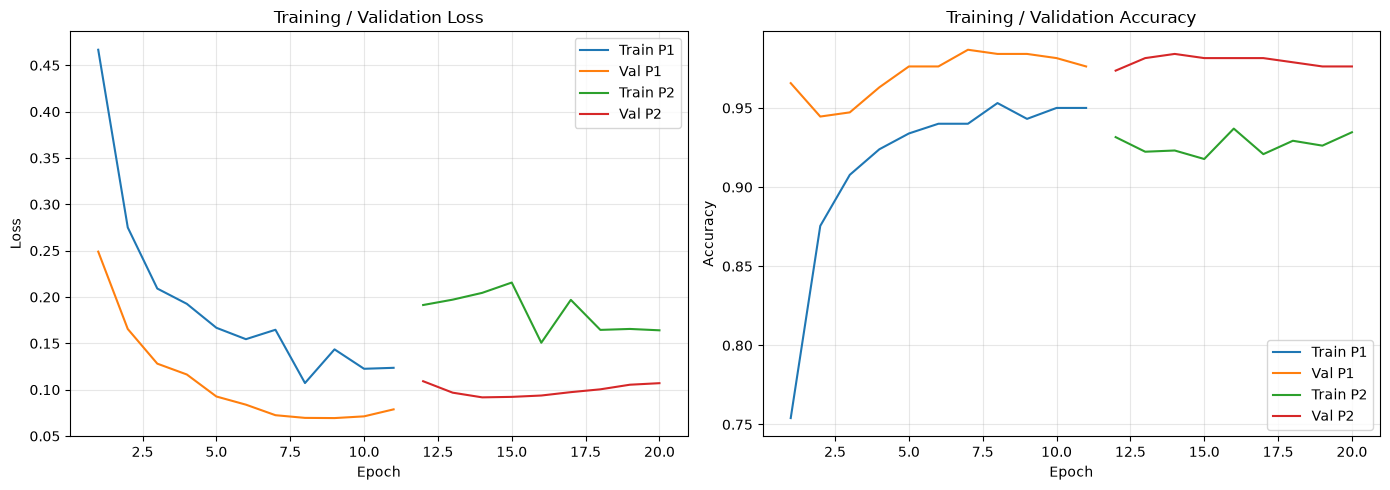

Saved: training_curves.png


In [6]:
# CELL 6 - Training curves
import math as _math

def plot_history(h1, h2=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for metric, ax, title in [("loss", axes[0], "Loss"), ("accuracy", axes[1], "Accuracy")]:
        ep1 = range(1, len(h1.history[metric]) + 1)
        ax.plot(ep1, h1.history[metric],         label="Train P1")
        ax.plot(ep1, h1.history[f"val_{metric}"], label="Val P1")
        if h2:
            ep2 = range(len(ep1) + 1, len(ep1) + len(h2.history[metric]) + 1)
            ax.plot(ep2, h2.history[metric],         label="Train P2")
            ax.plot(ep2, h2.history[f"val_{metric}"], label="Val P2")
        ax.set_title(f"Training / Validation {title}")
        ax.set_xlabel("Epoch"); ax.set_ylabel(title)
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(str(REPORT_DIR / "training_curves.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: training_curves.png")

plot_history(history_p1, history_p2 if PHASE2_RAN else None)


In [7]:
# CELL 7 - Load best model and evaluate on test set
best_model = keras.models.load_model(str(MODEL_PATH))
print("Loaded best model from:", MODEL_PATH)

test_gen.reset()
y_prob = best_model.predict(test_gen, verbose=1).flatten()
y_true = test_gen.classes
y_pred = (y_prob >= 0.5).astype(int)

acc      = accuracy_score(y_true, y_pred)
bal_acc  = balanced_accuracy_score(y_true, y_pred)
roc_auc  = roc_auc_score(y_true, y_prob)
macro_f1 = f1_score(y_true, y_pred, average="macro")
cm_arr   = confusion_matrix(y_true, y_pred)
prec, rec, f1s, sup = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1])
report   = classification_report(y_true, y_pred, target_names=["Cataract", "Normal"])

print("\n" + "="*60)
print("TEST SET EVALUATION")
print("="*60)
print(f"NOTE: Normal test set has only {TEST_COUNTS['Normal']} samples -> high metric uncertainty for Normal class")
print(f"\nAccuracy          : {acc:.4f}")
print(f"Balanced Accuracy : {bal_acc:.4f}")
print(f"Macro F1          : {macro_f1:.4f}")
print(f"ROC-AUC           : {roc_auc:.4f}")
print(f"\nCataract(0) -> Precision:{prec[0]:.4f}  Recall:{rec[0]:.4f}  F1:{f1s[0]:.4f}  n={int(sup[0])}")
print(f"Normal  (1) -> Precision:{prec[1]:.4f}  Recall:{rec[1]:.4f}  F1:{f1s[1]:.4f}  n={int(sup[1])}")
print(f"\nConfusion Matrix [Cataract, Normal]:")
print(cm_arr)
print("\nClassification Report:")
print(report)


Loaded best model from: d:\Practice Projects\Disease Detection\model\camera_binary_classifier_best.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step 

TEST SET EVALUATION
NOTE: Normal test set has only 29 samples -> high metric uncertainty for Normal class

Accuracy          : 0.9526
Balanced Accuracy : 0.8448
Macro F1          : 0.8946
ROC-AUC           : 0.9724

Cataract(0) -> Precision:0.9471  Recall:1.0000  F1:0.9728  n=161
Normal  (1) -> Precision:1.0000  Recall:0.6897  F1:0.8163  n=29

Confusion Matrix [Cataract, Normal]:
[[161   0]
 [  9  20]]

Classification Report:
              precision    recall  f1-score   support

    Cataract       0.95      1.00      0.97       161
      Normal       1.00      0.69      0.82        29

    accuracy                           0.95       190
   macro avg       0.97      0.84      0.89       190
weighted avg       0.96      0.95      0.95       190



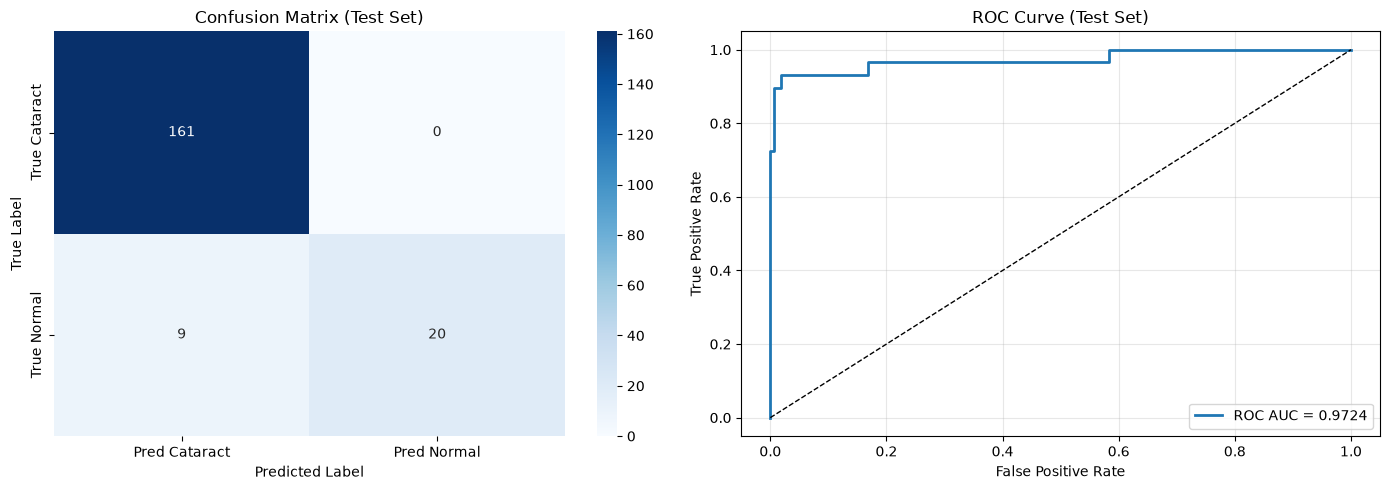

Saved: confusion_matrix_roc.png


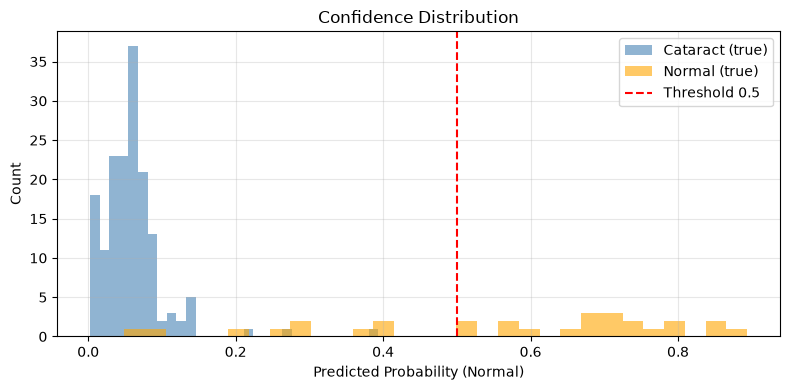

Saved: confidence_distribution.png
Correct   (181): mean conf=0.1303  std=0.2082
Incorrect (9): mean conf=0.2614  std=0.1225


In [8]:
# CELL 8 - Confusion matrix, ROC curve, confidence distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_arr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Cataract", "Pred Normal"],
            yticklabels=["True Cataract", "True Normal"], ax=axes[0])
axes[0].set_title("Confusion Matrix (Test Set)")
axes[0].set_ylabel("True Label"); axes[0].set_xlabel("Predicted Label")

fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[1].plot(fpr, tpr, lw=2, label=f"ROC AUC = {roc_auc:.4f}")
axes[1].plot([0,1],[0,1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve (Test Set)"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(REPORT_DIR / "confusion_matrix_roc.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix_roc.png")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_prob[y_true == 0], bins=30, alpha=0.6, label="Cataract (true)", color="steelblue")
ax.hist(y_prob[y_true == 1], bins=30, alpha=0.6, label="Normal (true)",   color="orange")
ax.axvline(0.5, color="red", linestyle="--", label="Threshold 0.5")
ax.set_xlabel("Predicted Probability (Normal)"); ax.set_ylabel("Count")
ax.set_title("Confidence Distribution"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(REPORT_DIR / "confidence_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confidence_distribution.png")

correct_mask   = (y_pred == y_true)
incorrect_mask = ~correct_mask
print(f"Correct   ({correct_mask.sum()}): mean conf={y_prob[correct_mask].mean():.4f}  std={y_prob[correct_mask].std():.4f}")
print(f"Incorrect ({incorrect_mask.sum()}): mean conf={y_prob[incorrect_mask].mean():.4f}  std={y_prob[incorrect_mask].std():.4f}")


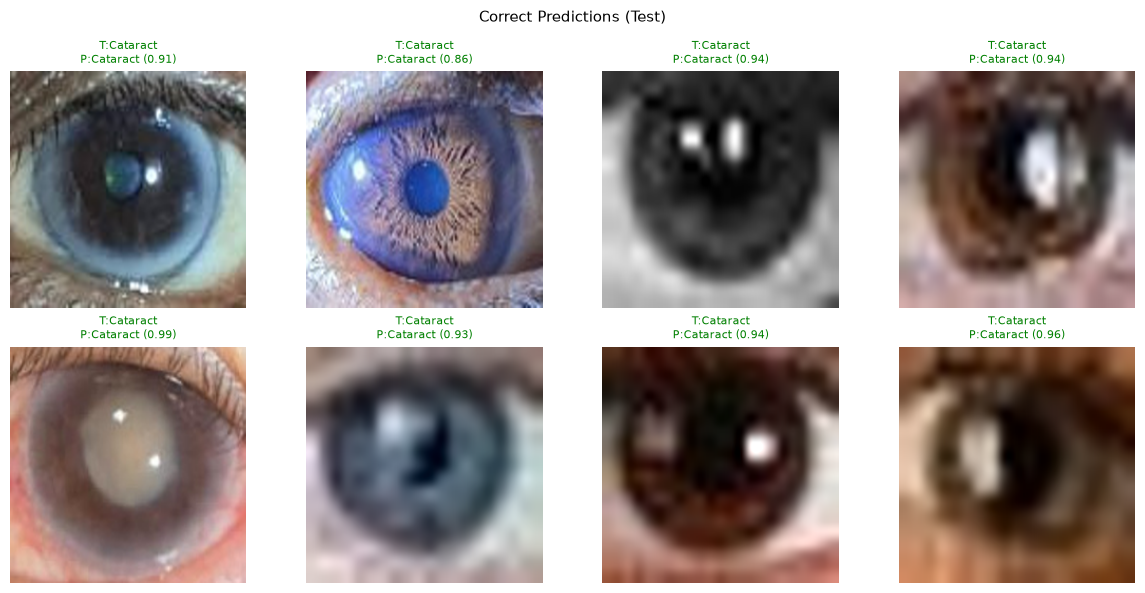

Saved: correct_predictions.png


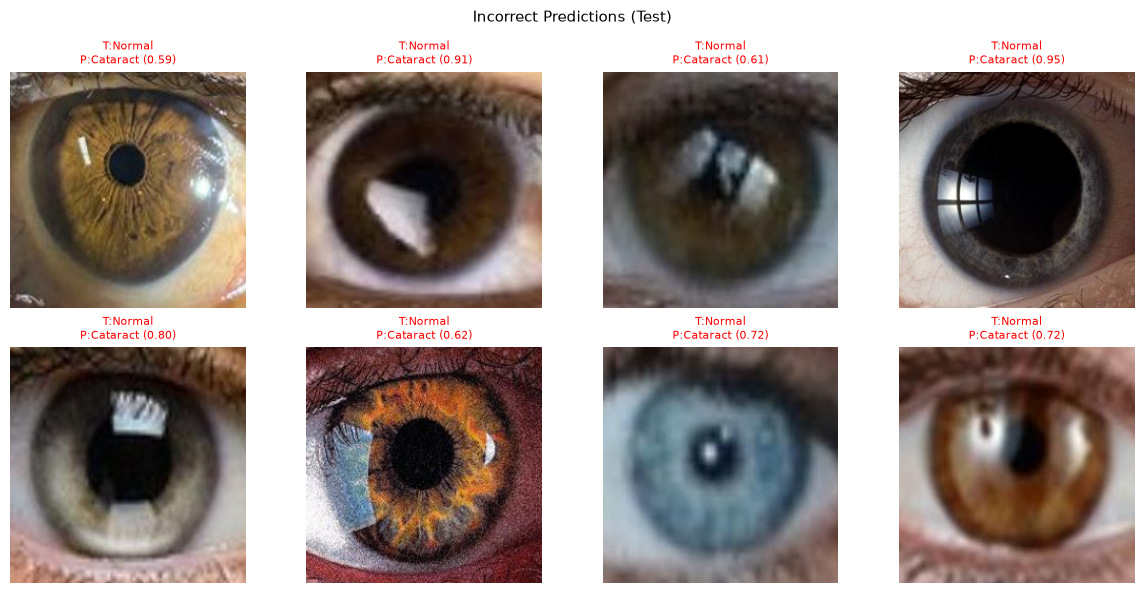

Saved: incorrect_predictions.png


In [9]:
# CELL 9 - Representative correct and incorrect predictions
import math as _math2

def show_samples(indices, title, save_name, n=8):
    indices = indices[:n]
    if len(indices) == 0:
        print(f"No samples for: {title}"); return
    cols = min(4, len(indices))
    rows = _math2.ceil(len(indices) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = np.array(axes).flatten()
    fnames = test_gen.filenames
    for i, idx in enumerate(indices):
        img_path = PREPARED_DIR / "test" / fnames[idx]
        img = Image.open(img_path).resize((224, 224))
        axes[i].imshow(img)
        true_lbl = CLASS_MAP[int(y_true[idx])]
        pred_lbl = CLASS_MAP[int(y_pred[idx])]
        conf     = float(y_prob[idx]) if y_pred[idx] == 1 else 1 - float(y_prob[idx])
        color    = "green" if y_pred[idx] == y_true[idx] else "red"
        axes[i].set_title(f"T:{true_lbl}\nP:{pred_lbl} ({conf:.2f})", fontsize=8, color=color)
        axes[i].axis("off")
    for j in range(len(indices), len(axes)):
        axes[j].axis("off")
    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.savefig(str(REPORT_DIR / save_name), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_name}")

show_samples(np.where(correct_mask)[0],   "Correct Predictions (Test)",   "correct_predictions.png")
show_samples(np.where(incorrect_mask)[0], "Incorrect Predictions (Test)", "incorrect_predictions.png")


Last conv layer for Grad-CAM: top_conv


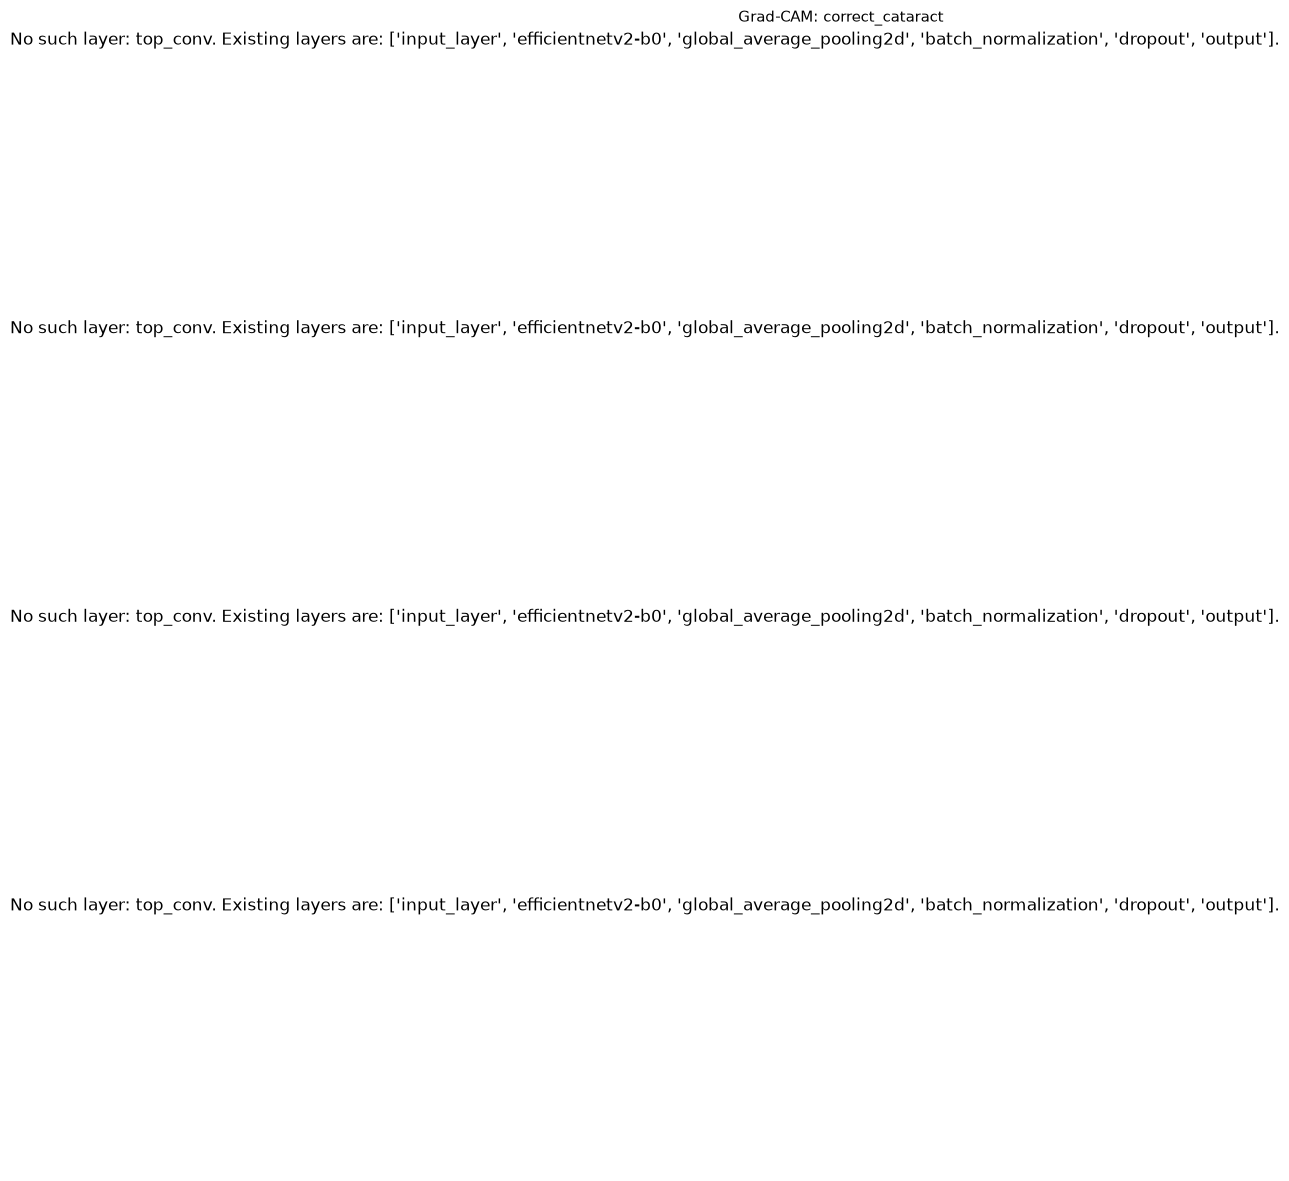

Saved: gradcam/gradcam_correct_cataract.png


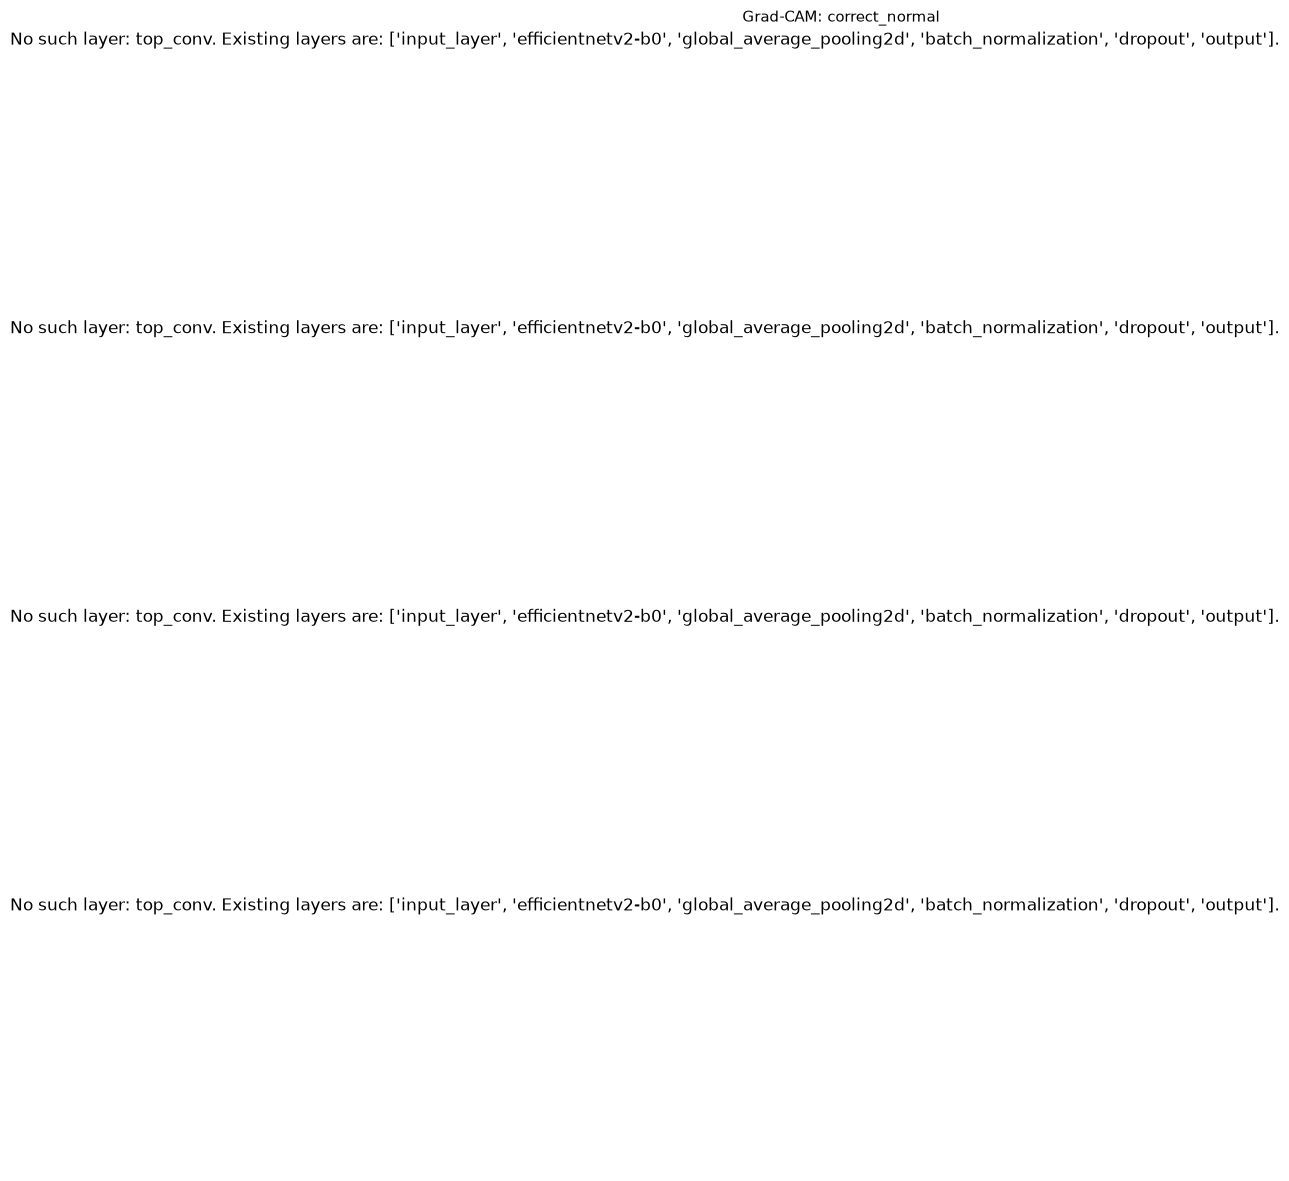

Saved: gradcam/gradcam_correct_normal.png


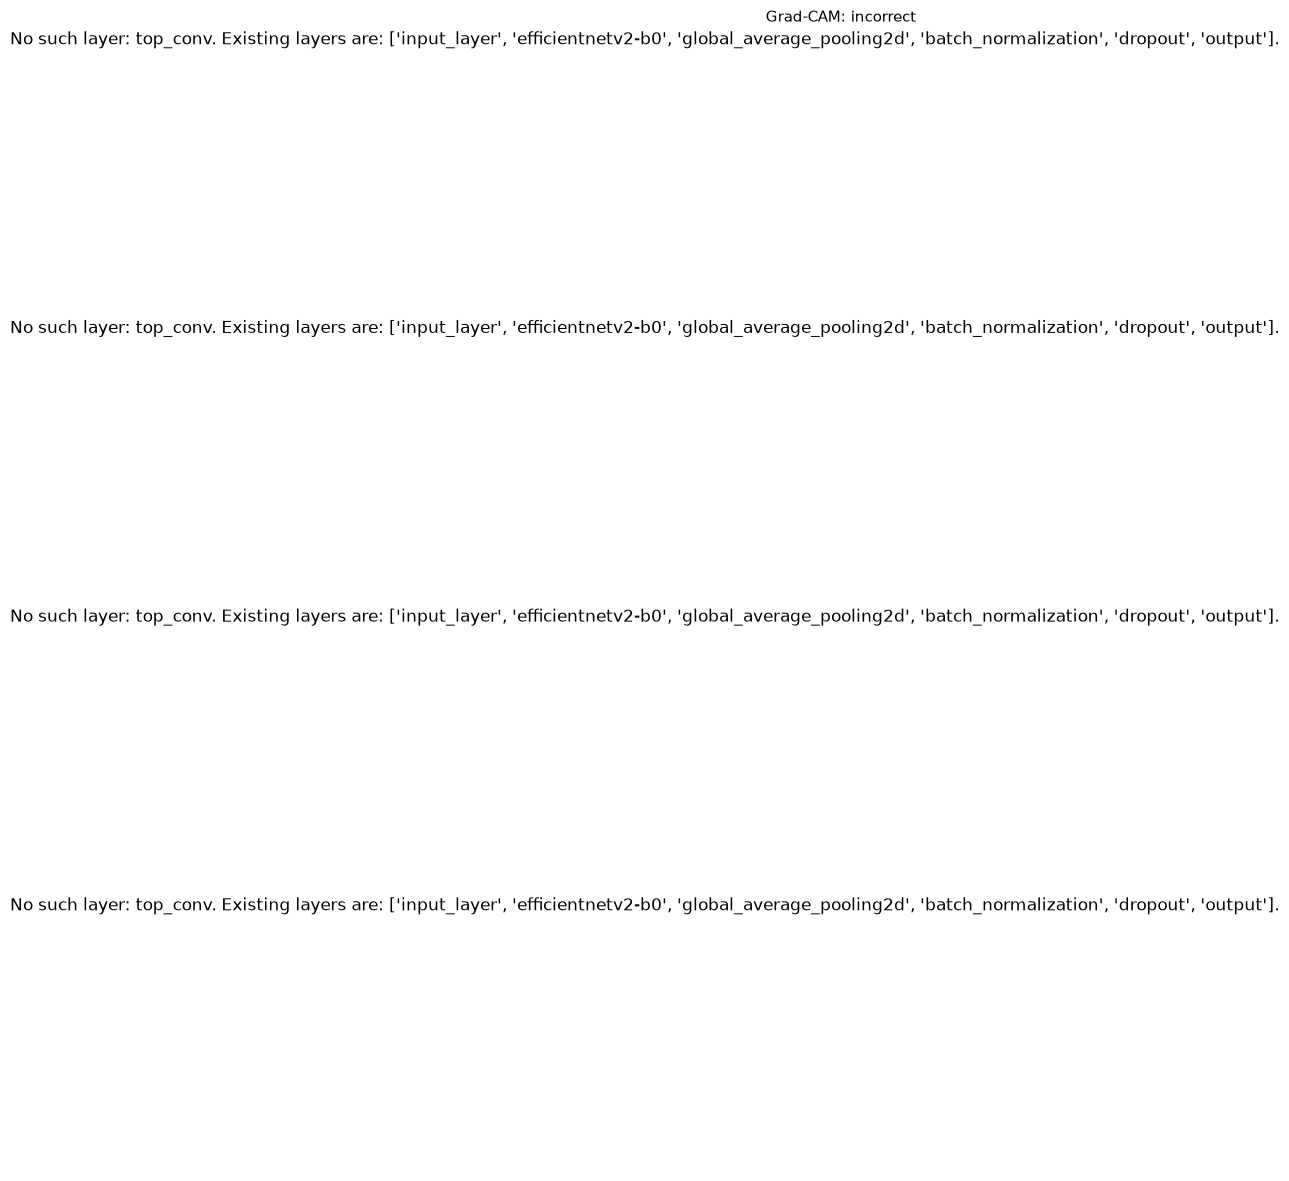

Saved: gradcam/gradcam_incorrect.png


In [10]:
# CELL 10 - Grad-CAM for camera binary classifier only
# Does NOT modify backend/app/gradcam.py
import cv2

def get_gradcam_heatmap(mdl, img_array, conv_layer_name):
    grad_model = Model(
        inputs=mdl.inputs,
        outputs=[mdl.get_layer(conv_layer_name).output, mdl.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        loss = preds[:, 0]
    grads = tape.gradient(loss, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_out[0] @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_gradcam(img_path, heatmap, alpha=0.4):
    img = np.array(Image.open(img_path).resize((224, 224)).convert("RGB"))
    h   = cv2.resize(heatmap, (224, 224))
    hc  = cv2.cvtColor(cv2.applyColorMap(np.uint8(255 * h), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    return img, (hc * alpha + img * (1 - alpha)).astype(np.uint8)

# Find last Conv2D layer name (search inside backbone sub-model)
last_conv = None
for layer in reversed(best_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv = layer.name; break
    if hasattr(layer, "layers"):
        for sub in reversed(layer.layers):
            if isinstance(sub, tf.keras.layers.Conv2D):
                last_conv = sub.name; break
    if last_conv:
        break
print("Last conv layer for Grad-CAM:", last_conv)

def run_gradcam(indices, label, n=4):
    indices = indices[:n]
    if not len(indices) or last_conv is None:
        print(f"Skipping Grad-CAM: {label}"); return
    fnames = test_gen.filenames
    fig, axes = plt.subplots(len(indices), 2, figsize=(8, len(indices) * 3))
    if len(indices) == 1: axes = [axes]
    for row, idx in enumerate(indices):
        img_path = PREPARED_DIR / "test" / fnames[idx]
        arr = preprocess_input(
            np.expand_dims(np.array(Image.open(img_path).resize((224,224)).convert("RGB")), 0).astype("float32")
        )
        try:
            hm = get_gradcam_heatmap(best_model, arr, last_conv)
            orig, ov = overlay_gradcam(img_path, hm)
            axes[row][0].imshow(orig);  axes[row][0].set_title("Original"); axes[row][0].axis("off")
            axes[row][1].imshow(ov);    axes[row][1].set_title("Grad-CAM"); axes[row][1].axis("off")
        except Exception as e:
            axes[row][0].set_title(str(e)); axes[row][0].axis("off"); axes[row][1].axis("off")
    fig.suptitle(f"Grad-CAM: {label}", fontsize=11)
    plt.tight_layout()
    sname = f"gradcam_{label.replace(' ','_')}.png"
    plt.savefig(str(GRADCAM_DIR / sname), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: gradcam/{sname}")

run_gradcam(np.where((y_true==0) & correct_mask)[0],  "correct_cataract")
run_gradcam(np.where((y_true==1) & correct_mask)[0],  "correct_normal")
run_gradcam(np.where(incorrect_mask)[0],              "incorrect")


In [11]:
# CELL 11 - predict_camera_eye helper
def predict_camera_eye(image_path: str) -> dict:
    """
    Predict Normal vs Cataract for a single camera eye image.
    Domain: camera-captured eye images only.
    Does NOT detect Diabetic Retinopathy or Glaucoma.
    """
    img = Image.open(image_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    arr = preprocess_input(np.expand_dims(np.array(img, dtype="float32"), 0))
    prob_normal   = float(best_model.predict(arr, verbose=0)[0][0])
    prob_cataract = 1.0 - prob_normal
    class_id      = 1 if prob_normal >= 0.5 else 0
    disease_name  = CLASS_MAP[class_id]
    confidence    = prob_normal if class_id == 1 else prob_cataract
    return {
        "disease_name": disease_name,
        "class_id":     class_id,
        "confidence":   round(confidence, 4),
        "probabilities": {"Cataract": round(prob_cataract, 4), "Normal": round(prob_normal, 4)},
        "domain_note":  "Detects Normal vs Cataract only. DR and Glaucoma are NOT supported.",
    }

sample_path = PREPARED_DIR / "test" / test_gen.filenames[0]
print("predict_camera_eye smoke test:")
print(json.dumps(predict_camera_eye(str(sample_path)), indent=2))


predict_camera_eye smoke test:
{
  "disease_name": "Cataract",
  "class_id": 0,
  "confidence": 0.575,
  "probabilities": {
    "Cataract": 0.575,
    "Normal": 0.425
  },
  "domain_note": "Detects Normal vs Cataract only. DR and Glaucoma are NOT supported."
}


In [12]:
# CELL 12 - Save metadata JSON
best_val_auc_final = max(
    (max(history_p2.history["val_auc"]) if PHASE2_RAN else 0),
    best_val_auc_p1
)
metadata = {
    "model_name":   "camera_binary_classifier",
    "model_path":   str(MODEL_PATH),
    "architecture": "EfficientNetV2B0 -> GlobalAveragePooling2D -> BatchNormalization -> Dropout(0.4) -> Dense(1,sigmoid)",
    "input_size":   [IMG_SIZE, IMG_SIZE, 3],
    "class_mapping": {"0": "Cataract", "1": "Normal"},
    "domain": "Camera-captured eye images. Normal and Cataract only. DR and Glaucoma NOT supported.",
    "dataset": {
        "train": TRAIN_COUNTS, "val": VAL_COUNTS, "test": TEST_COUNTS,
        "train_total": TRAIN_TOTAL, "val_total": VAL_TOTAL, "test_total": TEST_TOTAL,
    },
    "class_imbalance": {
        "cataract_pct": round(TRAIN_COUNTS["Cataract"] / TRAIN_TOTAL * 100, 2),
        "normal_pct":   round(TRAIN_COUNTS["Normal"]   / TRAIN_TOTAL * 100, 2),
    },
    "class_weights":       {str(k): round(v, 6) for k, v in class_weight.items()},
    "class_weight_method": "inverse-frequency: total / (2 * class_count)",
    "augmentation": {
        "rotation_range": 10, "horizontal_flip": True,
        "zoom_range": 0.08, "width_shift_range": 0.06, "height_shift_range": 0.06,
        "brightness_range": [0.85, 1.15], "applied_to": "train only",
    },
    "optimizer": "Adam",
    "phase1_lr": 1e-3, "phase2_lr": 1e-5 if PHASE2_RAN else None,
    "phase2_ran": PHASE2_RAN,
    "phase1_epochs_run": len(history_p1.history["loss"]),
    "phase2_epochs_run": len(history_p2.history["loss"]) if PHASE2_RAN else 0,
    "best_val_auc": round(float(best_val_auc_final), 6),
    "test_metrics": {
        "accuracy":           round(float(acc),      4),
        "balanced_accuracy":  round(float(bal_acc),  4),
        "macro_f1":           round(float(macro_f1), 4),
        "roc_auc":            round(float(roc_auc),  4),
        "cataract_precision": round(float(prec[0]),  4),
        "cataract_recall":    round(float(rec[0]),   4),
        "cataract_f1":        round(float(f1s[0]),   4),
        "normal_precision":   round(float(prec[1]),  4),
        "normal_recall":      round(float(rec[1]),   4),
        "normal_f1":          round(float(f1s[1]),   4),
        "confusion_matrix":   cm_arr.tolist(),
        "normal_sample_warning": f"Only {TEST_COUNTS['Normal']} Normal test samples; Normal metrics have high uncertainty.",
    },
    "training_date": datetime.now(timezone.utc).isoformat(),
    "isolation_verified": {
        "fundus_model_modified":    False,
        "fundus_accuracy_modified": False,
        "fundus_dataset_modified":  False,
        "backend_modified":         False,
        "frontend_modified":        False,
    },
}
meta_path = REPORT_DIR / "camera_classifier_metadata.json"
meta_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")
print("Metadata saved to:", meta_path)


Metadata saved to: d:\Practice Projects\Disease Detection\reports\camera_classifier\camera_classifier_metadata.json


In [13]:
# CELL 13 - Isolation validation + final status report
print("=" * 60)
print("ISOLATION VALIDATION")
print("=" * 60)
all_ok = True
for rel, before in PROTECTED_BEFORE.items():
    after = _fingerprint(PROJECT_ROOT / rel)
    if not before["exists"]:
        status = "SKIP (did not exist before)"
    elif before["md5"] != after["md5"] or before["mtime_ns"] != after["mtime_ns"]:
        status = "MODIFIED  <-- WARNING"; all_ok = False
    else:
        status = "UNCHANGED OK"
    print(f"  {rel:<55} {status}")

new_model_exists = MODEL_PATH.exists()
print(f"\n  New model exists ({MODEL_PATH.name}): {new_model_exists}")
if not new_model_exists:
    all_ok = False

overall = "PASS" if all_ok else "FAIL"

prototype_ok = (bal_acc >= 0.65 and roc_auc >= 0.70 and not (acc > 0.85 and rec[1] < 0.3))

print("\n" + "=" * 60)
print(f"CAMERA BINARY CLASSIFIER STATUS: {overall}")
print("=" * 60)
print(f"\nDataset:")
print(f"  Train      = {TRAIN_TOTAL}")
print(f"  Validation = {VAL_TOTAL}")
print(f"  Test       = {TEST_TOTAL}")
print(f"  Total      = {TRAIN_TOTAL + VAL_TOTAL + TEST_TOTAL}")
print(f"\nClass mapping:")
print(f"  0 = Cataract")
print(f"  1 = Normal")
print(f"\nTest metrics:")
print(f"  Accuracy          = {acc:.4f}")
print(f"  Balanced Accuracy = {bal_acc:.4f}")
print(f"  Macro F1          = {macro_f1:.4f}")
print(f"  ROC-AUC           = {roc_auc:.4f}")
print(f"  Normal Precision  = {prec[1]:.4f}")
print(f"  Normal Recall     = {rec[1]:.4f}")
print(f"  Normal F1         = {f1s[1]:.4f}")
print(f"  Cataract Precision= {prec[0]:.4f}")
print(f"  Cataract Recall   = {rec[0]:.4f}")
print(f"  Cataract F1       = {f1s[0]:.4f}")
print(f"\nConfusion Matrix (rows=true, cols=pred) [Cataract, Normal]:")
print(f"  {cm_arr.tolist()}")
print(f"\nModel:")
print(f"  camera_binary_classifier_best.keras")
print(f"\nExisting fundus model modified   : NO")
print(f"Existing 84.94% accuracy modified: NO")
print(f"Existing 5885 dataset modified   : NO")
print(f"Backend modified                 : NO")
print(f"Frontend modified                : NO")
print(f"\nNOTE: Normal test set has only {TEST_COUNTS['Normal']} samples.")
print(f"      Normal-class metrics have HIGH uncertainty.")
print()
if prototype_ok:
    print("CONCLUSION: The camera classifier shows sufficient discriminative ability")
    print("(ROC-AUC and balanced accuracy above baseline) to serve as a prototype")
    print("Normal-vs-Cataract camera classifier. Validation on a larger Normal set")
    print("is strongly recommended before any production use.")
else:
    print("CONCLUSION: The camera classifier does NOT yet meet prototype quality.")
    print("The model is biased toward Cataract due to severe class imbalance.")
    print("Collect more Normal camera images before deploying.")
print()
print("NEXT STEP = evaluate the camera classifier results and decide whether")
print("additional camera datasets for Diabetic Retinopathy and Glaucoma are")
print("required before building the final 4-class camera pipeline.")


ISOLATION VALIDATION
  preprocessing/dataset_metadata_v2.csv                   UNCHANGED OK
  preprocessing/splits_v2/train.csv                       UNCHANGED OK
  preprocessing/splits_v2/validation.csv                  UNCHANGED OK
  preprocessing/splits_v2/test.csv                        UNCHANGED OK
  model/efficientnetv2_b0_4class_best.keras               UNCHANGED OK
  model/efficientnetv2_b0_4class_final.keras              UNCHANGED OK
  model/model_metadata_v2.json                            UNCHANGED OK
  reports/model_v2/test_metrics.json                      UNCHANGED OK
  backend/app/main.py                                     UNCHANGED OK
  backend/app/model_service.py                            UNCHANGED OK
  backend/app/gradcam.py                                  UNCHANGED OK
  frontend/package.json                                   UNCHANGED OK

  New model exists (camera_binary_classifier_best.keras): True

CAMERA BINARY CLASSIFIER STATUS: PASS

Dataset:
  Train      =